In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Union, List
from copy import copy
from sklearn.metrics import mean_squared_error

from pytorch_forecasting import (
    TimeSeriesDataSet,
    BaseModelWithCovariates,
    MultiEmbedding,
    get_embedding_size,
)
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, RMSE, MAPE, MASE, MultiHorizonMetric

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.callbacks.progress import TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'


In [2]:
class _CausalConv1d(nn.Module):
    """Dilated causal 1-D convolution (no future leakage)."""
    def __init__(self, in_c: int, out_c: int, k: int, d: int):
        super().__init__()
        pad = (k - 1) * d
        self.conv  = nn.Conv1d(in_c, out_c, k, padding=pad, dilation=d)
        self.chomp = pad

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv(x)
        return out[..., : -self.chomp] if self.chomp > 0 else out


class _TCNBlock(nn.Module):
    """Residual TCN block with two causal dilated convolutions."""
    def __init__(self, in_c: int, out_c: int, k: int, d: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            _CausalConv1d(in_c, out_c, k, d), nn.ReLU(), nn.Dropout(dropout),
            _CausalConv1d(out_c, out_c, k, d), nn.ReLU(), nn.Dropout(dropout),
        )
        self.skip = nn.Conv1d(in_c, out_c, 1) if in_c != out_c else None
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.relu(self.net(x) + (x if self.skip is None else self.skip(x)))


class TemporalConvNet(BaseModelWithCovariates):
    """
    Temporal Convolutional Network for multi-horizon forecasting.

    Encodes the encoder sequence with dilated causal convolutions,
    then projects the last hidden vector to all prediction steps.
    The receptive field with n_layers=4, kernel_size=4 covers 46 steps,
    which exceeds the default MAX_ENCODER_LENGTH=36.
    """

    def __init__(
        self,
        hidden_size:          int = 64,
        kernel_size:          int = 4,
        n_layers:             int = 4,
        dropout:              float = 0.1,
        max_prediction_length: int = 36,
        # ── covariate args injected by from_dataset ──────────────────────
        static_categoricals:               Optional[List[str]] = None,
        static_reals:                      Optional[List[str]] = None,
        time_varying_categoricals_encoder: Optional[List[str]] = None,
        time_varying_categoricals_decoder: Optional[List[str]] = None,
        categorical_groups:                Optional[dict]      = None,
        time_varying_reals_encoder:        Optional[List[str]] = None,
        time_varying_reals_decoder:        Optional[List[str]] = None,
        embedding_sizes:                   Optional[dict]      = None,
        embedding_paddings:                Optional[List[str]] = None,
        embedding_labels:                  Optional[dict]      = None,
        x_reals:                           Optional[List[str]] = None,
        x_categoricals:                    Optional[List[str]] = None,
        output_size:   Union[int, List[int]] = 1,
        target:        Union[str, List[str]] = None,
        loss:          MultiHorizonMetric    = None,
        logging_metrics: nn.ModuleList       = None,
        **kwargs,
    ):
        if loss            is None: loss            = RMSE()
        if logging_metrics is None: logging_metrics = nn.ModuleList([SMAPE(), MAE(), RMSE(), MAPE(), MASE()])
        if static_categoricals               is None: static_categoricals               = []
        if static_reals                      is None: static_reals                      = []
        if time_varying_categoricals_encoder is None: time_varying_categoricals_encoder = []
        if time_varying_categoricals_decoder is None: time_varying_categoricals_decoder = []
        if categorical_groups                is None: categorical_groups                = {}
        if time_varying_reals_encoder        is None: time_varying_reals_encoder        = []
        if time_varying_reals_decoder        is None: time_varying_reals_decoder        = []
        if embedding_sizes                   is None: embedding_sizes                   = {}
        if embedding_paddings                is None: embedding_paddings                = []
        if embedding_labels                  is None: embedding_labels                  = {}
        if x_reals                           is None: x_reals                           = []
        if x_categoricals                    is None: x_categoricals                    = []

        self.save_hyperparameters()
        super().__init__(loss=loss, logging_metrics=logging_metrics, **kwargs)

        self.embeddings = MultiEmbedding(
            embedding_sizes=embedding_sizes,
            embedding_paddings=embedding_paddings,
            categorical_groups=categorical_groups,
            x_categoricals=x_categoricals,
        )

        cont_size  = len(self.reals)
        cat_size   = sum(self.embeddings.output_size.values())
        input_size = cont_size + cat_size

        # TCN: n_layers residual blocks, dilation doubles each layer
        channels = [input_size] + [hidden_size] * n_layers
        self.tcn = nn.Sequential(*[
            _TCNBlock(channels[i], channels[i + 1], kernel_size, 2 ** i, dropout)
            for i in range(n_layers)
        ])

        out_sz = output_size if isinstance(output_size, int) else sum(output_size)
        self.output_projector = nn.Linear(hidden_size, max_prediction_length * out_sz)

    # ── from_dataset ─────────────────────────────────────────────────────
    @classmethod
    def from_dataset(cls, dataset, allowed_encoder_known_variable_names=None, **kwargs):
        kwargs.setdefault('max_prediction_length', dataset.max_prediction_length)
        kwargs.setdefault('target', dataset.target)
        new_kwargs = copy(kwargs)
        new_kwargs.update(
            cls.deduce_default_output_parameters(dataset=dataset, kwargs=kwargs, default_loss=RMSE())
        )
        return super().from_dataset(
            dataset,
            allowed_encoder_known_variable_names=allowed_encoder_known_variable_names,
            **new_kwargs,
        )

    # ── forward ──────────────────────────────────────────────────────────
    def forward(self, x: dict) -> dict:
        enc_cat  = x["encoder_cat"]
        enc_cont = x["encoder_cont"]

        # Build feature vector (same pattern as RecurrentNetwork)
        if len(self.categoricals) > 0:
            embs    = self.embeddings(enc_cat)
            flat_emb = torch.cat(list(embs.values()), dim=-1)
            iv = flat_emb
        if len(self.reals) > 0:
            iv = enc_cont.clone()
        if len(self.reals) > 0 and len(self.categoricals) > 0:
            iv = torch.cat([enc_cont, flat_emb], dim=-1)

        # TCN: (B, T_enc, F) → (B, F, T_enc) → (B, hidden, T_enc)
        tcn_out = self.tcn(iv.transpose(1, 2))
        last    = tcn_out[..., -1]                 # (B, hidden)

        # Project to all decoder steps
        raw    = self.output_projector(last)       # (B, max_pred * out_sz)
        B      = raw.size(0)
        pred_l = self.hparams.max_prediction_length
        out_sz = (self.hparams.output_size
                  if isinstance(self.hparams.output_size, int)
                  else sum(self.hparams.output_size))
        pred   = raw.view(B, pred_l, out_sz)

        # Slice to actual decoder length in this batch
        T_dec  = x["decoder_cont"].size(1)
        pred   = pred[:, :T_dec, :]

        pred = self.transform_output(pred, target_scale=x["target_scale"])
        return self.to_network_output(prediction=pred)

In [3]:
def smallest_int_dtype(min_val: int, max_val: int, signed: bool = True) -> str:
    if signed:
        for t in ["int8", "int16", "int32"]:
            info = np.iinfo(t)
            if info.min <= min_val <= max_val <= info.max:
                return t
        return "int64"
    else:
        for t in ["uint8", "uint16", "uint32"]:
            if 0 <= min_val <= max_val <= np.iinfo(t).max:
                return t
        return "uint64"


def optimize_df_for_memory(df: pd.DataFrame) -> tuple:
    meta = {}
    for col in df.columns:
        s = df[col]
        unique_non_null = set(df[col].dropna().unique())
        if unique_non_null.issubset({0, 1, True, False}) and col == "Група":
            df[col] = s.astype("bool")
            meta[col] = {"stored_as": "bool", "scale": 1}
            continue
        if pd.api.types.is_integer_dtype(s):
            mn, mx = int(s.min()), int(s.max())
            dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
            df[col] = s.astype(dtype)
            meta[col] = {"stored_as": dtype, "scale": 1}
            continue
        if pd.api.types.is_float_dtype(s):
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}
                continue
            decimals = non_null.astype(str).apply(
                lambda x: len(x.split(".")[1].rstrip("0")) if "." in x else 0
            ).max()
            if decimals <= 3:
                scale = 10 ** decimals
                scaled = np.round(s * scale)
                mn, mx = int(np.nanmin(scaled)), int(np.nanmax(scaled))
                int_dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
                if np.dtype(int_dtype).itemsize < np.dtype("float32").itemsize:
                    df[col] = scaled.astype(int_dtype)
                    meta[col] = {"stored_as": int_dtype, "scale": scale}
                    continue
            df[col] = s.astype("float32")
            meta[col] = {"stored_as": "float32", "scale": 1}
    return df, meta

In [4]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / np.maximum(denom, 1e-8))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [5]:
TRAIN_PATH = "../../../data/silver_money_calc/train.parquet"
VAL_PATH   = "../../../data/silver_money_calc/val.parquet"
TEST_PATH  = "../../../data/silver_money_calc/test.parquet"

Y_COL     = "Sum of кВт"
GROUP_COL = "EIC-код_cat"

In [6]:
FUTURE_REALS = [
    "temperature_2m", "apparent_temperature",
    "dew_point_2m", "relative_humidity_2m", "precipitation", "rain",
    "snowfall", "cloud_cover", "cloud_cover_low", "cloud_cover_mid",
    "cloud_cover_high", "surface_pressure", "wind_speed_10m",
    "wind_direction_10m", "wind_gusts_10m", "shortwave_radiation",
    "diffuse_radiation", "direct_normal_irradiance",
]

weather_cols_to_drop = [
    "apparent_temperature", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "surface_pressure", "wind_direction_10m", "wind_gusts_10m",
    "diffuse_radiation", "direct_normal_irradiance",
]

PAST_REALS   = []
STATIC_REALS = ["Широта", "Довгота"]

TIME_VARYING_KNOWN_CATS = ["Month_cat", "Day_cat", "Hour_cat", "day_of_week_cat", "season_cat"]

STATIC_CATS = [
    "EIC-код_cat", "Група_cat", "АЗС_cat", "Тип_cat",
    "Область_cat", "ОСР код_cat", "ОСР опис_cat",
]

In [7]:
MAX_PREDICTION_LENGTH = 36
MAX_ENCODER_LENGTH    = 36

BATCH_SIZE    = 1024 * 2
MAX_EPOCHS    = 50
LEARNING_RATE = 3e-3

# CNN-specific hyperparameters
HIDDEN_SIZE = 64
KERNEL_SIZE = 4
N_LAYERS    = 4      # TCN residual blocks (receptive field ≈ 46 steps)
DROPOUT     = 0.1

In [8]:
GLOBAL_MIN_DT = None


def build_time_index(df: pd.DataFrame) -> pd.DataFrame:
    global GLOBAL_MIN_DT
    df["datetime"] = pd.to_datetime(df["datetime"])
    if GLOBAL_MIN_DT is None:
        GLOBAL_MIN_DT = df["datetime"].min()
    df["time_idx"] = (
        (df["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600
    ).astype(int)
    return df


def add_cat_helpers(df: pd.DataFrame) -> pd.DataFrame:
    df["datetime"]        = pd.to_datetime(df["datetime"])
    df["Month_cat"]       = df["datetime"].dt.month.astype(str)
    df["Day_cat"]         = df["datetime"].dt.day.astype(str)
    df["Hour_cat"]        = df["datetime"].dt.hour.astype(str)
    df["day_of_week_cat"] = df["datetime"].dt.dayofweek.astype(str)
    season_map = {
        12: "winter", 1: "winter", 2: "winter",
        3: "spring",  4: "spring", 5: "spring",
        6: "summer",  7: "summer", 8: "summer",
        9: "autumn", 10: "autumn", 11: "autumn",
    }
    df["season_cat"] = df["datetime"].dt.month.map(season_map)
    return df


def load_and_prepare(path: str, has_y: bool = True) -> pd.DataFrame:
    df = pd.read_parquet(path).reset_index(drop=True)
    df = df[df["datetime"] >= "2024-06-30"].reset_index(drop=True)
    df.columns = df.columns.str.replace(".", "_", regex=False)
    df, _ = optimize_df_for_memory(df)
    for col in df.select_dtypes(
        include=["int8", "int16", "int32", "uint8", "uint16", "uint32"]
    ).columns:
        df[col] = df[col].astype("float32")
    df = build_time_index(df)
    df = add_cat_helpers(df)
    for col in df.columns:
        if col.endswith("_cat"):
            df[col] = df[col].astype(str)
    if has_y:
        df[Y_COL] = df[Y_COL].astype("float32")
    else:
        df[Y_COL] = 0.0
    df = df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
    try:
        df.drop(columns=["Ціна розподілу ЕЕ", "Ціна ЕЕ", "Money_spent"], inplace=True)
    except KeyError:
        pass
    df.drop(columns=[c for c in weather_cols_to_drop if c in df.columns], inplace=True)
    return df

In [9]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH)
print(f"train: {train.shape}  range: {train['datetime'].min()} → {train['datetime'].max()}")

print("Loading val   …")
val = load_and_prepare(VAL_PATH)

print("Loading test  …")
test = load_and_prepare(TEST_PATH)

print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
train: (3309985, 23)  range: 2024-06-30 00:00:00+03:00 → 2025-06-30 23:00:00+03:00
Loading val   …
Loading test  …
val : (304499, 23)
test: (304152, 23)


In [10]:
station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)
sampled_stations = station_stats[GROUP_COL].values
print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 409
Train rows : 3,309,985
Val rows   : 304,499
Test rows  : 303,408


In [11]:
train["data_subset"] = "train"
val["data_subset"]   = "val"
test["data_subset"]  = "test"

all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
)

# Normalise timezone so PTF doesn't choke on mixed-tz datetimes
all_data["datetime"] = pd.to_datetime(all_data["datetime"], utc=True, errors="coerce")
all_data["datetime"] = all_data["datetime"].dt.tz_convert(None)
all_data["time_idx"] = (
    (all_data["datetime"] - all_data["datetime"].min()).dt.total_seconds() // 3600
).astype("int64")

training_cutoff = all_data.loc[all_data["data_subset"] == "train", "time_idx"].max()
val_cutoff      = all_data.loc[all_data["data_subset"] == "val",   "time_idx"].max()
test_cutoff     = all_data.loc[all_data["data_subset"] == "test",  "time_idx"].max()
all_data.drop(columns=["data_subset"], inplace=True)

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

def filter_existing(lst, df):
    return [c for c in lst if c in df.columns]

training = TimeSeriesDataSet(
    all_data[all_data["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target=Y_COL,
    group_ids=[GROUP_COL],
    min_encoder_length=MAX_ENCODER_LENGTH // 2,
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=1,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=filter_existing(STATIC_CATS, all_data),
    static_reals=filter_existing(STATIC_REALS, all_data),
    time_varying_known_reals=filter_existing(FUTURE_REALS, all_data) + ["time_idx"],
    time_varying_known_categoricals=filter_existing(TIME_VARYING_KNOWN_CATS, all_data),
    time_varying_unknown_reals=[Y_COL] + filter_existing(PAST_REALS, all_data),
    target_normalizer=GroupNormalizer(groups=[GROUP_COL], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    all_data[all_data["time_idx"] <= val_cutoff],
    predict=True,
    stop_randomization=True,
)

NUM_WORKERS = 0
train_loader = training.to_dataloader(
    train=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = validation.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"\nTraining   batches : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")

training cutoff : 8783
val cutoff      : 9527
test cutoff     : 10272

Training   batches : 1628
Validation batches : 1


In [12]:
cnn = TemporalConvNet.from_dataset(
    training,
    learning_rate=LEARNING_RATE,
    hidden_size=HIDDEN_SIZE,
    kernel_size=KERNEL_SIZE,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    loss=RMSE(),
    optimizer="adam",
    reduce_on_plateau_patience=4,
    log_interval=-1,
)
print(f"Number of parameters: {cnn.size() / 1e3:.1f}k")

Number of parameters: 188.0k


In [13]:
class MetricPrinterCallback(pl.Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        m = trainer.callback_metrics
        print(
            f"[epoch={trainer.current_epoch:3d} | step={trainer.global_step:6d}]"
            f"  train_loss={float(m.get('train_loss', float('nan'))):.4f}"
            f"  val_loss={float(m.get('val_loss', float('nan'))):.4f}"
        )


early_stop = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=5, verbose=True, mode="min",
)
lr_logger  = LearningRateMonitor()
checkpoint = ModelCheckpoint(
    dirpath="checkpoints/cnn/",
    filename="cnn-{epoch:02d}-{val_loss:.4f}",
    monitor="val_loss",
    mode="min",
    save_top_k=2,
)
progress_bar = TQDMProgressBar(refresh_rate=20)
logger = TensorBoardLogger("../tb_logs", name="cnn_gas_stations")

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
print(f"Using {accelerator} accelerator")

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop, lr_logger, checkpoint, progress_bar, MetricPrinterCallback()],
    logger=logger,
    enable_progress_bar=True,
    log_every_n_steps=10,
    precision="bf16-mixed",
    val_check_interval=0.25,
    accumulate_grad_batches=4,
)

Using gpu accelerator

Using bfloat16 Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [14]:
trainer.fit(
    cnn,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

print(f"\nBest checkpoint : {checkpoint.best_model_path}")
print(f"Best val_loss   : {checkpoint.best_model_score:.6f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss             │ RMSE           │      0 │ train │     0 │
│ 1 │ logging_metrics  │ ModuleList     │      0 │ train │     0 │
│ 2 │ embeddings       │ MultiEmbedding │ 22.4 K │ train │     0 │
│ 3 │ tcn              │ Sequential     │  163 K │ train │     0 │
│ 4 │ output_projector │ Linear         │  2.3 K │ train │     0 │
└───┴──────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 187 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 187 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 68                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

[epoch=  1 | step=   814]  train_loss=6.5455  val_loss=8.0198


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 5 records. Best score: 7.911. Signaling Trainer to stop.


[epoch=  2 | step=   915]  train_loss=4.0281  val_loss=8.5926

Best checkpoint : C:\Users\Lev\Documents\GitHub\Diploma\checkpoints\cnn\cnn-epoch=00-val_loss=7.9110.ckpt
Best val_loss   : 7.911007


In [15]:
best_cnn = TemporalConvNet.load_from_checkpoint(
    checkpoint.best_model_path,
    weights_only=False,
)
best_cnn.eval()

# Quick sanity check on the last validation window
result = best_cnn.predict(
    val_loader,
    return_index=True,
    trainer_kwargs={"accelerator": accelerator},
)

pred_tensor = result[0].cpu().numpy()
val_index   = result[2]

rows = []
for i, (_, idx_row) in enumerate(val_index.iterrows()):
    for step in range(MAX_PREDICTION_LENGTH):
        rows.append({
            GROUP_COL:  idx_row[GROUP_COL],
            "time_idx": idx_row["time_idx"] + step,
            "pred":     pred_tensor[i, step],
        })

val_expanded = pd.DataFrame(rows)
val_merged   = val_expanded.merge(
    all_data[[GROUP_COL, "time_idx", Y_COL]],
    on=[GROUP_COL, "time_idx"], how="inner",
)

print(f"Aligned samples: {len(val_merged)}")
print("\n── Quick Val Metrics (last window only) ──────────────────")
print(f"SMAPE : {smape(val_merged[Y_COL], val_merged['pred']):.4f}")
print(f"RMSE  : {rmse( val_merged[Y_COL], val_merged['pred']):.4f}")
print(f"MAPE  : {mape( val_merged[Y_COL], val_merged['pred']):.2f} %")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Aligned samples: 20204

── Quick Val Metrics (last window only) ──────────────────
SMAPE : 0.2429
RMSE  : 8.9714
MAPE  : 32.87 %


In [16]:
def rolling_eval(model, base_dataset, full_data, start_idx, end_idx):
    """
    Slide MAX_PREDICTION_LENGTH-step windows over (start_idx, end_idx].
    Actual y values are used as encoder context — no error propagation.
    """
    records = []
    for window_end in range(
        start_idx + MAX_PREDICTION_LENGTH,
        end_idx + 1,
        MAX_PREDICTION_LENGTH,
    ):
        ds = TimeSeriesDataSet.from_dataset(
            base_dataset,
            full_data[full_data["time_idx"] <= window_end],
            predict=True,
            stop_randomization=True,
        )
        loader = ds.to_dataloader(
            train=False, batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS, pin_memory=True,
        )
        result = model.predict(
            loader, return_index=True,
            trainer_kwargs={"accelerator": accelerator},
        )
        pred_np = result[0].cpu().numpy()
        for i, (_, idx_row) in enumerate(result[2].iterrows()):
            for s in range(MAX_PREDICTION_LENGTH):
                t = idx_row["time_idx"] + s
                if t > end_idx:
                    break
                records.append({
                    GROUP_COL:  idx_row[GROUP_COL],
                    "time_idx": t,
                    "pred":     pred_np[i, s],
                })

    preds_df = pd.DataFrame(records)
    return preds_df.merge(
        full_data[[GROUP_COL, "time_idx", Y_COL]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )


labelled_data = all_data[all_data["time_idx"] <= test_cutoff]

print("── Validation ──────────────────────────────────────────────")
val_eval = rolling_eval(best_cnn, training, labelled_data, training_cutoff, val_cutoff)
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse( val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape( val_eval[Y_COL], val_eval['pred']):.2f} %")

print("\n── Test ────────────────────────────────────────────────────")
test_eval = rolling_eval(best_cnn, training, labelled_data, val_cutoff, test_cutoff)
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse( test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape( test_eval[Y_COL], test_eval['pred']):.2f} %")

── Validation ──────────────────────────────────────────────


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless

Aligned samples : 293,760
SMAPE : 0.3052
RMSE  : 10.4021
MAPE  : 36.71 %

── Test ────────────────────────────────────────────────────


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless

Aligned samples : 293,320
SMAPE : 0.1334
RMSE  : 8.3819
MAPE  : 16.77 %


In [17]:
print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse( val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape( val_eval[Y_COL], val_eval['pred']):.2f} %")

print("\n── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse( test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape( test_eval[Y_COL], test_eval['pred']):.2f} %")

── Validation ──────────────────────────────────────────────
Aligned samples : 293,760
SMAPE : 0.3052
RMSE  : 10.4021
MAPE  : 36.71 %

── Test ────────────────────────────────────────────────────
Aligned samples : 293,320
SMAPE : 0.1334
RMSE  : 8.3819
MAPE  : 16.77 %


In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    df = eval_df.merge(
        all_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  RMSE={rmse(df[Y_COL], df['pred']):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

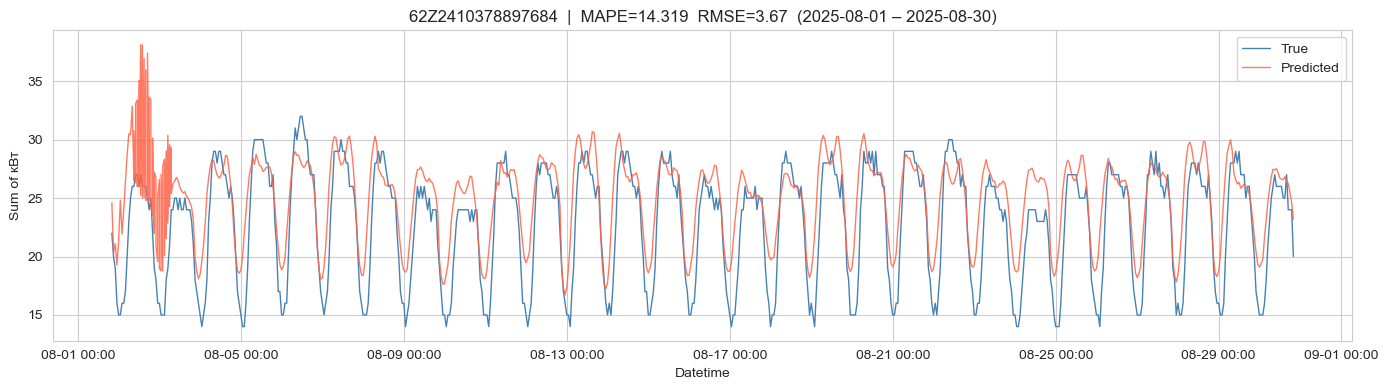

In [19]:
plot_forecast(test_eval, eic_code='62Z2410378897684')